# 5 · From point masses to a rigid body

**Math primer — notebook 5 of 7.**

Everything so far had one or two scalar coordinates. An engine on mounts has six,
and its mass matrix contains an *inertia tensor* rather than a number. This
notebook builds that tensor from scratch and shows exactly where the paper's
$I_{zx}$ comes from.

**You should come out knowing:** what a product of inertia is, why principal axes
are the eigenvectors of the inertia tensor, how a tensor transforms under
rotation, and why a tilted principal axis makes roll and yaw talk to each other.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
import primer
from primer import SERIES, INK, INK2, GRID, tidy
primer.use_style()

## 5.1 · Six coordinates

$$\{q\}=[x,\ y,\ z,\ \phi,\ \theta,\ \psi]^\mathsf{T}$$

Three translations of the centre of gravity, three small rotations about it. With
the CG as origin the kinetic energy splits cleanly:

$$T=\tfrac12 m\,\{\dot u\}^\mathsf{T}\{\dot u\}
   +\tfrac12\{\dot\omega\}^\mathsf{T}[J]\{\dot\omega\}
\qquad\Rightarrow\qquad
[M]=\begin{bmatrix}m[I_3]&0\\0&[J]\end{bmatrix}$$

There is no translation–rotation coupling **only because** the origin is the CG.
Put it anywhere else and the off-diagonal blocks reappear — exactly as in the bar
of notebook 4, where offsetting $P$ from the CG created $M_{12}=me$.

## 5.2 · The inertia tensor, from point masses

For a set of point masses $m_i$ at positions $\{r_i\}$ relative to the CG,

$$[J]=\sum_i m_i\left(\|r_i\|^2[I_3]-\{r_i\}\{r_i\}^\mathsf{T}\right)$$

The diagonal entries are the familiar moments of inertia. The off-diagonal
entries, $-\sum m_i x_i z_i$ and so on, are the **products of inertia**. They are
zero only if the mass is symmetric about the coordinate planes.

Careful with signs: the tensor entry is $J_{xz}=-\sum m_i x_i z_i$, whereas the
quantity the paper calls $I_{zx}$ is $\sum m_i x_i z_i$. So $J_{xz}=-I_{zx}$,
which is why the paper's mass matrix shows $-I_{zx}$ in the $\phi\psi$ slot.

In [2]:
def inertia_from_points(masses, positions):
    """Inertia tensor about the centre of mass of a cloud of point masses."""
    m = np.asarray(masses, float)
    r = np.asarray(positions, float)
    cg = (m[:, None] * r).sum(0) / m.sum()
    d = r - cg
    J = np.zeros((3, 3))
    for mi, di in zip(m, d):
        J += mi * (di @ di * np.eye(3) - np.outer(di, di))
    return J, cg, m.sum()

# a crude "engine": a heavy crankcase low and rearward, two lighter cylinders
# leaning forward and up.
masses = [22.0, 8.0, 8.0, 2.0]
positions = [[-0.05, 0.00, -0.09],     # crankcase
             [ 0.07, 0.035, 0.11],     # cylinder 1
             [ 0.07, -0.035, 0.11],    # cylinder 2
             [-0.18, 0.00, 0.02]]      # gearbox / clutch
J, cg, m_tot = inertia_from_points(masses, positions)
print(f"total mass {m_tot:.1f} kg, CG at {cg} m\n")
print("inertia tensor about the CG [kg m^2]:\n", J)
print("\nproduct of inertia J_xz =", J[0, 2],
      "  ->  the paper's I_zx =", -J[0, 2])

total mass 40.0 kg, CG at [-0.0085  0.     -0.0045] m

inertia tensor about the CG [kg m^2]:
 [[ 0.3914  0.     -0.2135]
 [ 0.      0.5671  0.    ]
 [-0.2135  0.      0.2149]]

product of inertia J_xz = -0.21346999999999997   ->  the paper's I_zx = 0.21346999999999997


## 5.3 · Principal axes are eigenvectors

There is always some rotated frame in which all products of inertia vanish. That
frame's axes are the **principal axes**, and finding them is an eigenproblem —
the ordinary symmetric one this time, because $[J]$ is symmetric:

$$[J]\{v\}=I\{v\}$$

In [3]:
Iprin, axes3 = np.linalg.eigh(J)
print("principal moments of inertia:", Iprin)
print("principal axes (columns):\n", axes3)
print("\ncheck: axes^T J axes is diagonal ->\n", axes3.T @ J @ axes3)

# the in-plane tilt, measured in the x-z plane
v = axes3[:, int(np.argmax(np.abs(axes3[0, :])))]   # the axis closest to x
if v[0] < 0:
    v = -v
alpha = np.arctan2(-v[2], v[0])
print(f"\nthe principal axis nearest x is tilted by {np.degrees(alpha):.2f} deg in the x-z plane")

principal moments of inertia: [0.0722 0.5341 0.5671]
principal axes (columns):
 [[-0.5559  0.8313 -0.    ]
 [ 0.      0.      1.    ]
 [-0.8313 -0.5559  0.    ]]

check: axes^T J axes is diagonal ->
 [[ 0.0722  0.      0.    ]
 [ 0.      0.5341 -0.    ]
 [ 0.     -0.      0.5671]]

the principal axis nearest x is tilted by 33.77 deg in the x-z plane


## 5.4 · Rotating a tensor — where Eq. (20) comes from

If the principal frame is reached by a rotation $[R]$, then in the working frame

$$[J]=[R]\,\mathrm{diag}(I_\xi,I_\eta,I_\zeta)\,[R]^\mathsf{T}$$

Note it is $R\,\Lambda\,R^\mathsf{T}$, *not* $R\Lambda$ — a tensor transforms on
both sides. Take $[R]$ to be a rotation by $\alpha$ about $y$ and multiply it out:

$$I_x=I_\xi\cos^2\alpha+I_\zeta\sin^2\alpha$$
$$I_z=I_\xi\sin^2\alpha+I_\zeta\cos^2\alpha$$
$$I_{zx}=(I_\xi-I_\zeta)\sin\alpha\cos\alpha$$

which is the paper's Eq. (20). Let's confirm it symbolically and numerically.

In [4]:
import sympy as sp

al, Ixi, Ieta, Izeta = sp.symbols("alpha I_xi I_eta I_zeta", real=True)
R = sp.Matrix([[sp.cos(al), 0, sp.sin(al)],
               [0, 1, 0],
               [-sp.sin(al), 0, sp.cos(al)]])
Jsym = sp.simplify(R * sp.diag(Ixi, Ieta, Izeta) * R.T)
print("J_xx  =", sp.simplify(Jsym[0, 0]))
print("J_zz  =", sp.simplify(Jsym[2, 2]))
print("J_xz  =", sp.simplify(sp.expand_trig(Jsym[0, 2])))
print("\nso I_zx = -J_xz =", sp.simplify(-Jsym[0, 2]))
print("   which is (I_xi - I_zeta) sin(a) cos(a):",
      sp.simplify(-Jsym[0, 2] - (Ixi - Izeta)*sp.sin(al)*sp.cos(al)) == 0)

J_xx  = I_xi*cos(alpha)**2 + I_zeta*sin(alpha)**2
J_zz  = I_xi*sin(alpha)**2 + I_zeta*cos(alpha)**2
J_xz  = (-I_xi + I_zeta)*sin(2*alpha)/2

so I_zx = -J_xz = (I_xi - I_zeta)*sin(2*alpha)/2
   which is (I_xi - I_zeta) sin(a) cos(a): True


In [5]:
def rot_y(a):
    c, s = np.cos(a), np.sin(a)
    return np.array([[c, 0, s], [0, 1.0, 0], [-s, 0, c]])

I_xi, I_eta, I_zeta = 0.95, 1.30, 1.60
for adeg in (0, 10, 30, 45, 90):
    a = np.deg2rad(adeg)
    Jn = rot_y(a) @ np.diag([I_xi, I_eta, I_zeta]) @ rot_y(a).T
    print(f"alpha = {adeg:3d} deg :  I_x = {Jn[0,0]:.4f}  I_z = {Jn[2,2]:.4f}  "
          f"I_zx = {-Jn[0,2]:+.4f}   (closed form {(I_xi-I_zeta)*np.sin(a)*np.cos(a):+.4f})")

alpha =   0 deg :  I_x = 0.9500  I_z = 1.6000  I_zx = -0.0000   (closed form -0.0000)
alpha =  10 deg :  I_x = 0.9696  I_z = 1.5804  I_zx = -0.1112   (closed form -0.1112)
alpha =  30 deg :  I_x = 1.1125  I_z = 1.4375  I_zx = -0.2815   (closed form -0.2815)
alpha =  45 deg :  I_x = 1.2750  I_z = 1.2750  I_zx = -0.3250   (closed form -0.3250)
alpha =  90 deg :  I_x = 1.6000  I_z = 0.9500  I_zx = -0.0000   (closed form -0.0000)


Read the last column. $I_{zx}$ is zero when $\alpha=0$ or $90°$ — when the
principal axes line up with the working axes — and largest at $45°$. It is
proportional to $(I_\xi-I_\zeta)$: a body whose two in-plane inertias are equal
has no product of inertia at any tilt.

## 5.5 · Why this couples roll and yaw

The rotational part of the equations of motion is
$[J]\{\dot\omega\}+\ldots=\{M\}$, with $\{\omega\}=[\dot\phi,\dot\theta,\dot\psi]$.
Written out, the $\phi$ row contains $J_{xz}\ddot\psi$: **an angular acceleration
about $z$ produces a moment about $x$.** So roll and yaw are inertially coupled
whenever $I_{zx}\ne 0$.

Physically: spin a tilted body about the vertical and it tries to wobble, because
its mass is not distributed symmetrically about that axis.

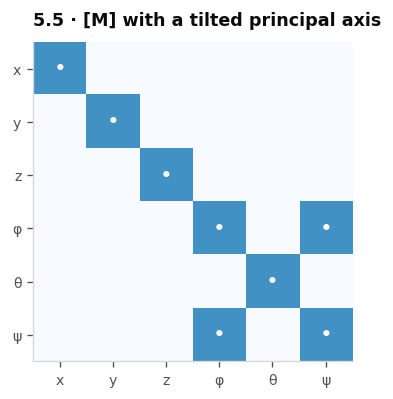

the only off-diagonal entries are the phi-psi pair: 0.2814582562299426 0.28145825622994264


In [6]:
alpha = np.deg2rad(30)
J30 = rot_y(alpha) @ np.diag([I_xi, I_eta, I_zeta]) @ rot_y(alpha).T
M6 = np.zeros((6, 6)); M6[:3, :3] = 40.0*np.eye(3); M6[3:, 3:] = J30
lab = ["x", "y", "z", "φ", "θ", "ψ"]

fig, ax = plt.subplots(figsize=(3.6, 3.4))
ax.imshow(np.abs(M6) > 1e-12, cmap="Blues", vmin=0, vmax=1.6)
for i in range(6):
    for j in range(6):
        if abs(M6[i, j]) > 1e-12:
            ax.text(j, i, "•", ha="center", va="center", color="white", fontsize=13)
ax.set_xticks(range(6)); ax.set_yticks(range(6))
ax.set_xticklabels(lab); ax.set_yticklabels(lab); ax.grid(False)
tidy(ax, "5.5 · [M] with a tilted principal axis")
plt.tight_layout(); plt.show()
print("the only off-diagonal entries are the phi-psi pair:", M6[3, 5], M6[5, 3])

Two dots off the diagonal, in the $\phi\psi$ slots. That single pair of entries is
the "dynamic coupling" the paper's abstract refers to, and the thing its elastic
design is going to be matched against.

---

**Next:** [6 · Mounts, stiffness matrices and the elastic centre](06_mounts_and_stiffness.ipynb)